# Comprensión del problema y Análisis Exploratorio de Datos (EDA)

## 1. Comprensión del problema

El objetivo del proyecto es desarrollar un modelo de Machine Learning capaz de predecir el **churn de clientes**, es decir, identificar clientes con mayor probabilidad de abandonar el servicio.

La variable objetivo del problema es `churn`:

- `churn = 0`: el cliente permanece.
- `churn = 1`: el cliente abandona.

La identificación anticipada de clientes con riesgo de churn puede permitir a la empresa implementar estrategias de retención antes de que se produzca el abandono.

En esta etapa se realizará un análisis exploratorio de los datos (EDA) para comprender las características de los clientes, analizar la distribución de las variables e identificar posibles relaciones entre estas y el churn.

In [ ]:
#Importamos las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Cargamos el dataset
df = pd.read_csv("../Base_de_datos.csv")
#Vemos las primeras 5 filas
df.head()

,customer_id,signup_month,age,tenure_months,region,channel,plan,sessions_week,avg_session_min,notif_click_rate,support_tickets_3m,discount_pct_3m,late_payments_6m,auto_renew,churn
0,C100000,10,71,49,South,web,Basic,4,10.11,0.318,0,0.138,0,1,0
1,C100001,22,53,44,West,store,Basic,3,6.55,0.329,0,0.000,0,0,0
2,C100002,10,56,51,South,web,Basic,6,12.10,0.120,0,0.001,1,1,0
3,C100003,22,69,48,Center,app,Basic,5,11.01,0.237,0,0.041,0,1,0
4,C100004,20,50,7,South,app,Basic,7,12.97,0.145,0,0.183,0,1,0


## 2. Análisis de la variable objetivo

Se analiza la distribución de la variable `churn` para determinar la proporción de clientes que permanecen y aquellos que abandonan el servicio.

In [ ]:
#Cuenta la cantidad de abandonos y no abandonos
df["churn"].value_counts()

churn
0    3782
1    1218
Name: count, dtype: int64

In [8]:
#Porcentaje de la cantidad de abandonos y no abandonos
df["churn"].value_counts(normalize=True) * 100

churn
0    75.64
1    24.36
Name: proportion, dtype: float64

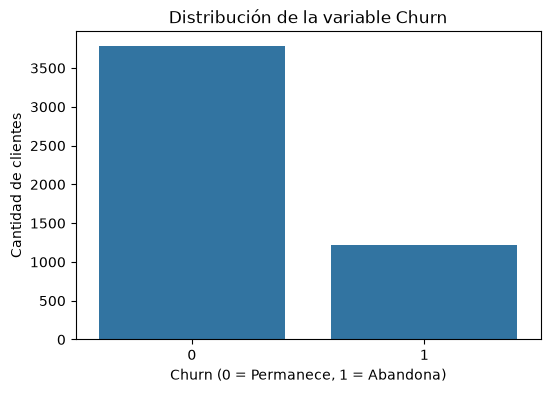

In [10]:
#Gráfico de la distribución de la variable churn
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="churn")

plt.title("Distribución de la variable Churn")
plt.xlabel("Churn (0 = Permanece, 1 = Abandona)")
plt.ylabel("Cantidad de clientes")

plt.show()

### Interpretación

La variable objetivo presenta una distribución desbalanceada: el 75,64 % de los clientes permanece en el servicio (`churn = 0`), mientras que el 24,36 % abandona (`churn = 1`).

Este desbalance deberá considerarse durante el entrenamiento y la evaluación de los modelos, ya que métricas como el accuracy podrían resultar insuficientes para evaluar correctamente la capacidad del modelo para detectar clientes que abandonan.

## 3. Análisis univariado

El análisis univariado permite estudiar cada variable de manera individual, observando su distribución, valores frecuentes, dispersión y posibles valores atípicos.

Se analizarán por separado las variables numéricas y categóricas.

In [12]:
#Descripciones estadísticas del dataset, el cual los damos vuelta.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
signup_month,5000.0,12.589000,6.987349,1.0,6.000,13.000,19.00000,24.000
age,5000.0,46.282400,16.330021,18.0,32.000,46.000,61.00000,74.000
tenure_months,5000.0,35.561200,20.579567,1.0,18.000,35.000,53.00000,71.000
sessions_week,5000.0,5.027600,2.238803,0.0,3.000,5.000,6.00000,14.000
avg_session_min,5000.0,12.044738,4.011593,1.0,9.310,12.000,14.75250,26.850
notif_click_rate,5000.0,0.183255,0.113473,0.0,0.100,0.179,0.25825,0.595
support_tickets_3m,5000.0,0.297400,0.541306,0.0,0.000,0.000,1.00000,4.000
discount_pct_3m,5000.0,0.092958,0.082765,0.0,0.015,0.081,0.14725,0.432
late_payments_6m,5000.0,0.201200,0.448953,0.0,0.000,0.000,0.00000,3.000
auto_renew,5000.0,0.396600,0.489241,0.0,0.000,0.000,1.00000,1.000


In [ ]:
#Seleccionamos las variables numéricas que queremos analizar
numeric_vars = [
    "age",
    "tenure_months",
    "sessions_week",
    "avg_session_min",
    "notif_click_rate",
    "support_tickets_3m",
    "discount_pct_3m",
    "late_payments_6m"
]

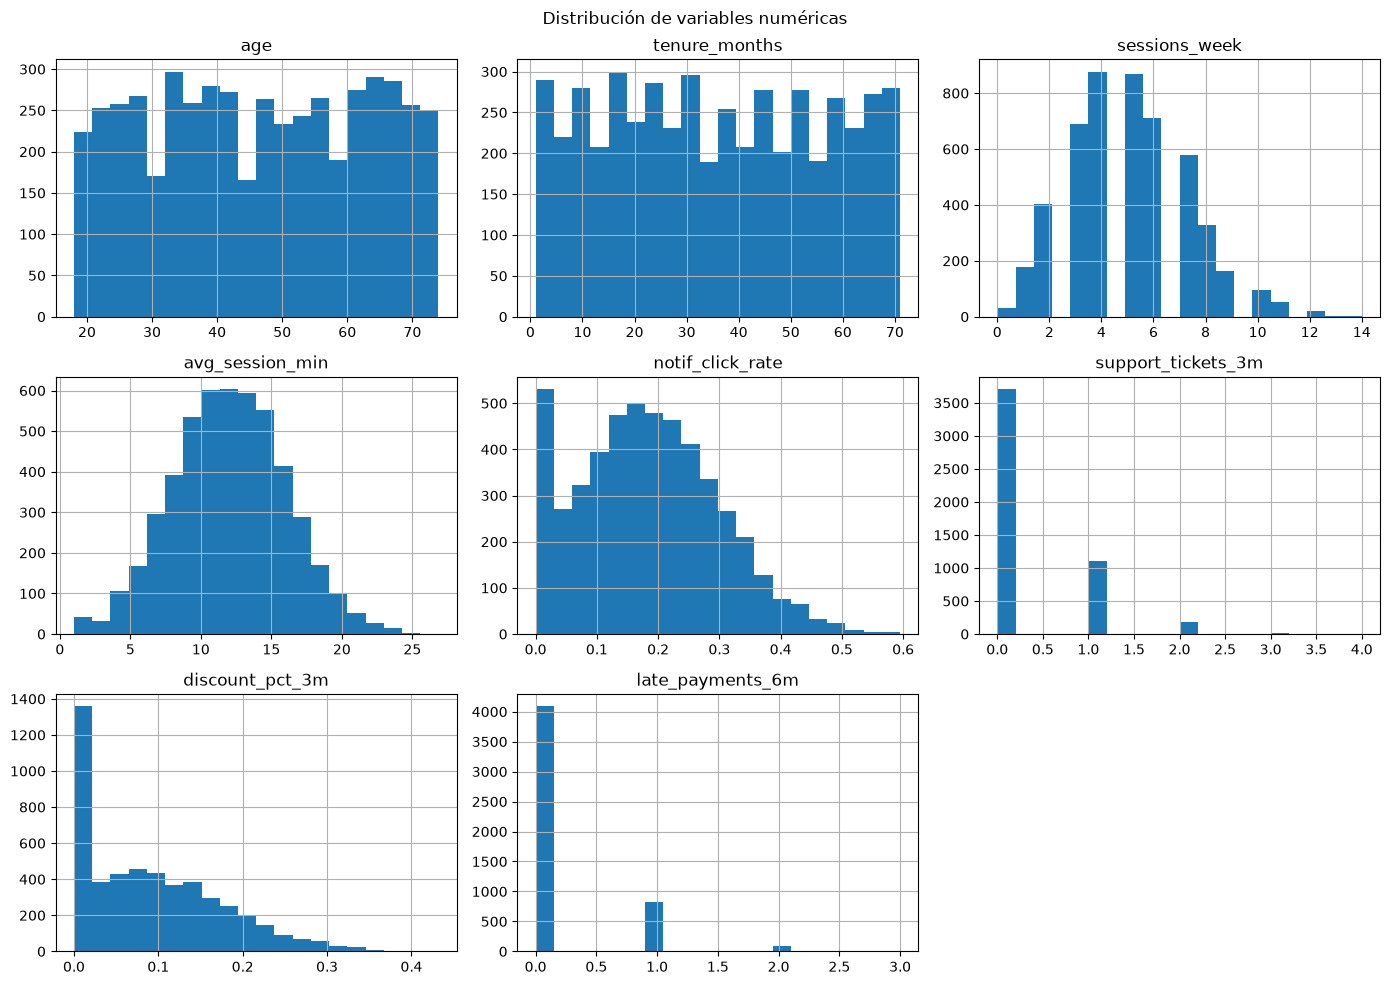

In [14]:
df[numeric_vars].hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

### Interpretación de las variables numéricas

El análisis univariado muestra distintos patrones de distribución entre las variables numéricas:

- `age` y `tenure_months` presentan valores distribuidos a lo largo de sus respectivos rangos, sin una concentración única claramente dominante.
- `sessions_week` se concentra principalmente alrededor de 4 a 6 sesiones semanales.
- `avg_session_min` presenta una distribución aproximadamente simétrica, con mayor concentración en valores intermedios.
- `notif_click_rate` presenta mayor concentración en valores bajos e intermedios y una cola hacia valores más elevados.
- `support_tickets_3m` y `late_payments_6m` se concentran fuertemente en cero, indicando que la mayoría de los clientes no registró tickets de soporte ni pagos atrasados en los períodos considerados.
- `discount_pct_3m` presenta mayor frecuencia en descuentos bajos y una disminución progresiva hacia porcentajes mayores.

Estas distribuciones permiten comprender el comportamiento general de las variables, aunque todavía no permiten determinar su relación con el churn. Para ello será necesario realizar posteriormente un análisis bivariado.

In [ ]:
#Seleccionamos las variables categóricas que queremos analizar
categorical_vars = ["region", "channel", "plan", "auto_renew"]
#Para cada columna de mi lista categorical_vars, 
#contame cuántas veces aparece cada categoría.for col in categorical_vars:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- region ---
region
Center    1310
North     1116
South      938
East       832
West       804
Name: count, dtype: int64

--- channel ---
channel
app      2453
web      1807
store     740
Name: count, dtype: int64

--- plan ---
plan
Basic      2274
Plus       1704
Premium    1022
Name: count, dtype: int64

--- auto_renew ---
auto_renew
0    3017
1    1983
Name: count, dtype: int64


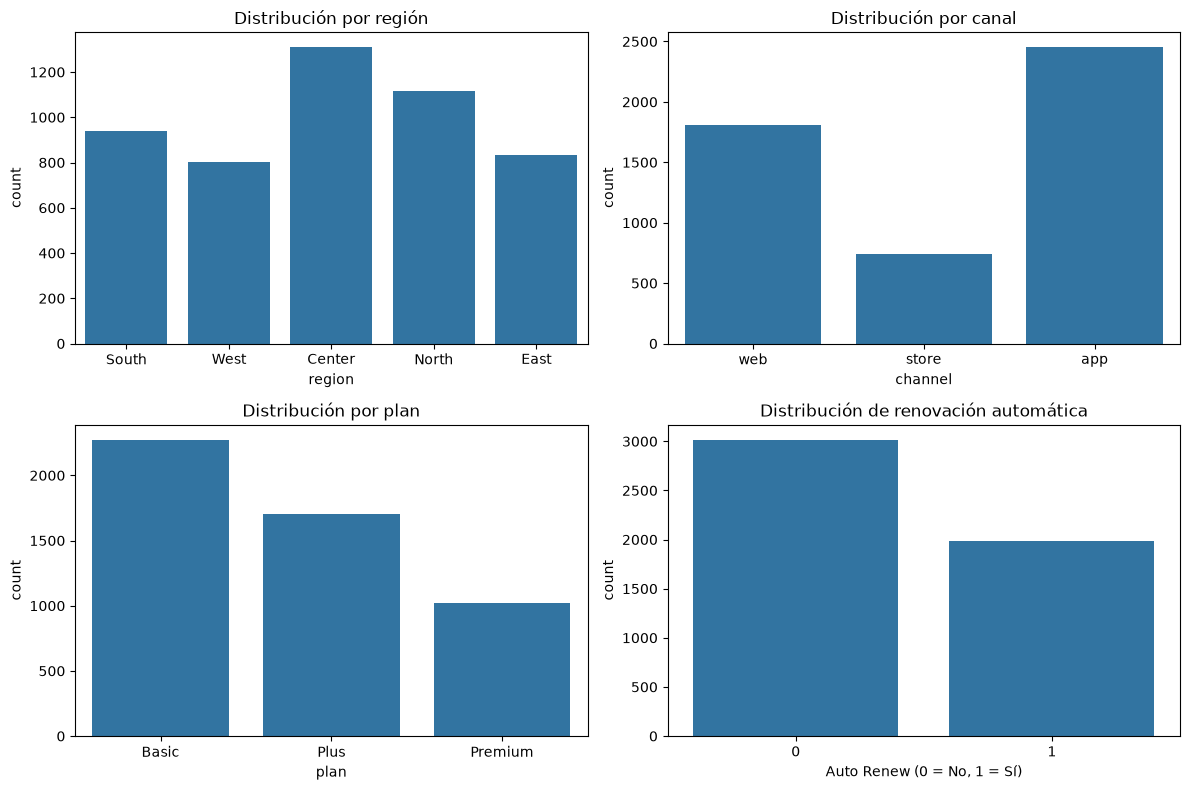

In [16]:
#Gráficos de variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=df, x="region", ax=axes[0, 0])
axes[0, 0].set_title("Distribución por región")

sns.countplot(data=df, x="channel", ax=axes[0, 1])
axes[0, 1].set_title("Distribución por canal")

sns.countplot(data=df, x="plan", ax=axes[1, 0])
axes[1, 0].set_title("Distribución por plan")

sns.countplot(data=df, x="auto_renew", ax=axes[1, 1])
axes[1, 1].set_title("Distribución de renovación automática")
axes[1, 1].set_xlabel("Auto Renew (0 = No, 1 = Sí)")

plt.tight_layout()
plt.show()

### Interpretación de las variables categóricas

- La región `Center` concentra la mayor cantidad de clientes, aunque existe representación de las cinco regiones.
- El canal `app` es el más utilizado, seguido por `web` y `store`.
- El plan `Basic` es el más frecuente, seguido por `Plus` y `Premium`.
- La mayoría de los clientes no posee renovación automática: 3.017 clientes presentan `auto_renew = 0`, frente a 1.983 con `auto_renew = 1`.

Este análisis describe la composición general de la base. Para determinar si estas características se encuentran asociadas con el abandono será necesario compararlas con la variable objetivo `churn`.

## 4. Análisis bivariado

El análisis bivariado busca identificar relaciones entre la variable objetivo `churn` y las distintas características de los clientes.

Para las variables categóricas se analizará principalmente la **tasa de churn dentro de cada categoría**, evitando interpretar únicamente cantidades absolutas, ya que los grupos poseen diferentes tamaños.

In [17]:
churn_by_plan = df.groupby("plan")["churn"].mean() * 100
churn_by_plan

plan
Basic      26.649077
Plus       24.823944
Premium    18.493151
Name: churn, dtype: float64

In [18]:
#Proporción de churn dentro de cada plan
df.groupby("plan")["churn"].mean()

plan
Basic      0.266491
Plus       0.248239
Premium    0.184932
Name: churn, dtype: float64

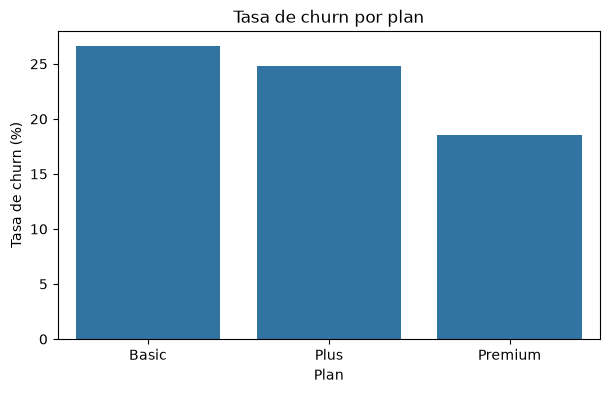

In [19]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=churn_by_plan.index,
    y=churn_by_plan.values
)

plt.title("Tasa de churn por plan")
plt.xlabel("Plan")
plt.ylabel("Tasa de churn (%)")

plt.show()

### Churn según el plan

La tasa de churn presenta diferencias entre los distintos planes:

- `Basic`: aproximadamente 26,65 %.
- `Plus`: aproximadamente 24,82 %.
- `Premium`: aproximadamente 18,49 %.

En este conjunto de datos, los clientes del plan Basic presentan la mayor tasa observada de churn, mientras que los clientes Premium presentan la menor.

Este resultado muestra una asociación entre el tipo de plan y el churn, aunque el análisis exploratorio por sí solo no permite establecer una relación causal.

In [23]:
#Proporción de abandonos respecto a renovación automatica o no
churn_by_renew = df.groupby("auto_renew")["churn"].mean() * 100
churn_by_renew.round(2)
#Recordando
#auto_renew = 0 → no tiene renovación automática
#auto_renew = 1 → sí tiene renovación automática

auto_renew
0    26.98
1    20.37
Name: churn, dtype: float64

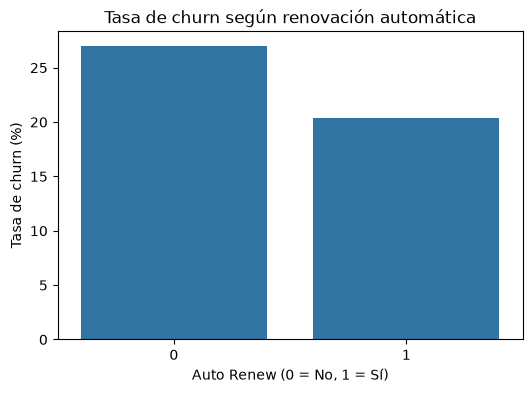

In [ ]:
#Gráfica de abandonos respecto a renovación automatica o no

plt.figure(figsize=(6, 4))

sns.barplot(
    x=churn_by_renew.index,
    y=churn_by_renew.values
)

plt.title("Tasa de churn según renovación automática")
plt.xlabel("Auto Renew (0 = No, 1 = Sí)")
plt.ylabel("Tasa de churn (%)")

plt.show()

### Churn según renovación automática

Los clientes sin renovación automática presentan una tasa de churn de aproximadamente 26,98 %, mientras que aquellos con renovación automática presentan una tasa de aproximadamente 20,37 %.

En este conjunto de datos se observa, por lo tanto, una menor tasa de churn entre los clientes que poseen renovación automática.

In [ ]:
#Proporción de abandono con respecto a región y canal de contratación
churn_by_region = df.groupby("region")["churn"].mean() * 100
churn_by_channel = df.groupby("channel")["churn"].mean() * 100

print("Tasa de churn por región:")
print(churn_by_region.round(2))

print("\nTasa de churn por canal:")
print(churn_by_channel.round(2))

Tasa de churn por región:
region
Center    25.34
East      22.48
North     24.82
South     26.23
West      21.89
Name: churn, dtype: float64

Tasa de churn por canal:
channel
app      24.05
store    26.35
web      23.96
Name: churn, dtype: float64


### Churn según región y canal

La tasa de churn presenta algunas diferencias según la región. `South` registra la mayor tasa observada (26,23 %), mientras que `West` presenta la menor (21,89 %).

En cuanto al canal, `store` presenta una tasa de churn ligeramente superior (26,35 %) respecto de `app` (24,05 %) y `web` (23,96 %). Las diferencias entre `app` y `web` son mínimas.

Estos resultados sugieren asociaciones entre estas variables categóricas y el churn, aunque las diferencias observadas deberán evaluarse posteriormente junto con el resto de las características mediante los modelos predictivos.

In [25]:
numeric_vars = [
    "age",
    "tenure_months",
    "sessions_week",
    "avg_session_min",
    "notif_click_rate",
    "support_tickets_3m",
    "discount_pct_3m",
    "late_payments_6m"
]

df.groupby("churn")[numeric_vars].mean().T.round(3)

churn,0,1
age,47.272,43.210
tenure_months,38.123,27.605
sessions_week,5.196,4.504
avg_session_min,12.120,11.811
notif_click_rate,0.188,0.167
support_tickets_3m,0.264,0.401
discount_pct_3m,0.095,0.088
late_payments_6m,0.189,0.241


### Relación entre variables numéricas y churn

La comparación de los valores promedio entre clientes que permanecen (`churn = 0`) y clientes que abandonan (`churn = 1`) permite identificar algunas diferencias:

- Los clientes con churn presentan una menor antigüedad promedio (27,61 meses) respecto de quienes permanecen (38,12 meses).
- Los clientes con churn registran una menor cantidad promedio de sesiones semanales (4,50 frente a 5,20).
- La edad promedio del grupo con churn es menor (43,21 años frente a 47,27 años).
- Los clientes con churn presentan una mayor cantidad promedio de tickets de soporte (0,401 frente a 0,264).
- También se observa una cantidad promedio ligeramente mayor de pagos atrasados entre los clientes con churn.
- Las diferencias en duración promedio de sesión y porcentaje de descuento son menores.

Estos resultados muestran asociaciones descriptivas entre determinadas características y el churn. Sin embargo, no permiten establecer relaciones causales ni determinar por sí solos la importancia predictiva de cada variable.

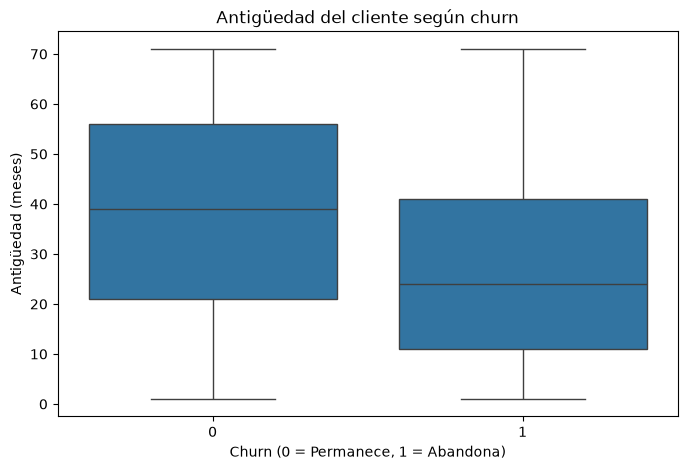

In [27]:
#Gráfico de antiguedad vs. churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="tenure_months"
)

plt.title("Antigüedad del cliente según churn")
plt.xlabel("Churn (0 = Permanece, 1 = Abandona)")
plt.ylabel("Antigüedad (meses)")

plt.show()

### Antigüedad según churn

El boxplot muestra diferencias en la distribución de la antigüedad entre ambos grupos.

Los clientes que presentan churn tienden a tener una menor antigüedad que aquellos que permanecen. La mediana de antigüedad del grupo `churn = 1` se encuentra por debajo de la correspondiente al grupo `churn = 0`.

Este resultado coincide con la comparación previa de los valores promedio y sugiere una asociación entre una menor antigüedad del cliente y una mayor presencia de churn.

## 5. Análisis multivariado

El análisis multivariado permite estudiar simultáneamente las relaciones entre distintas variables.

Se analizará la correlación entre las variables numéricas para identificar posibles asociaciones entre ellas y con la variable objetivo `churn`.

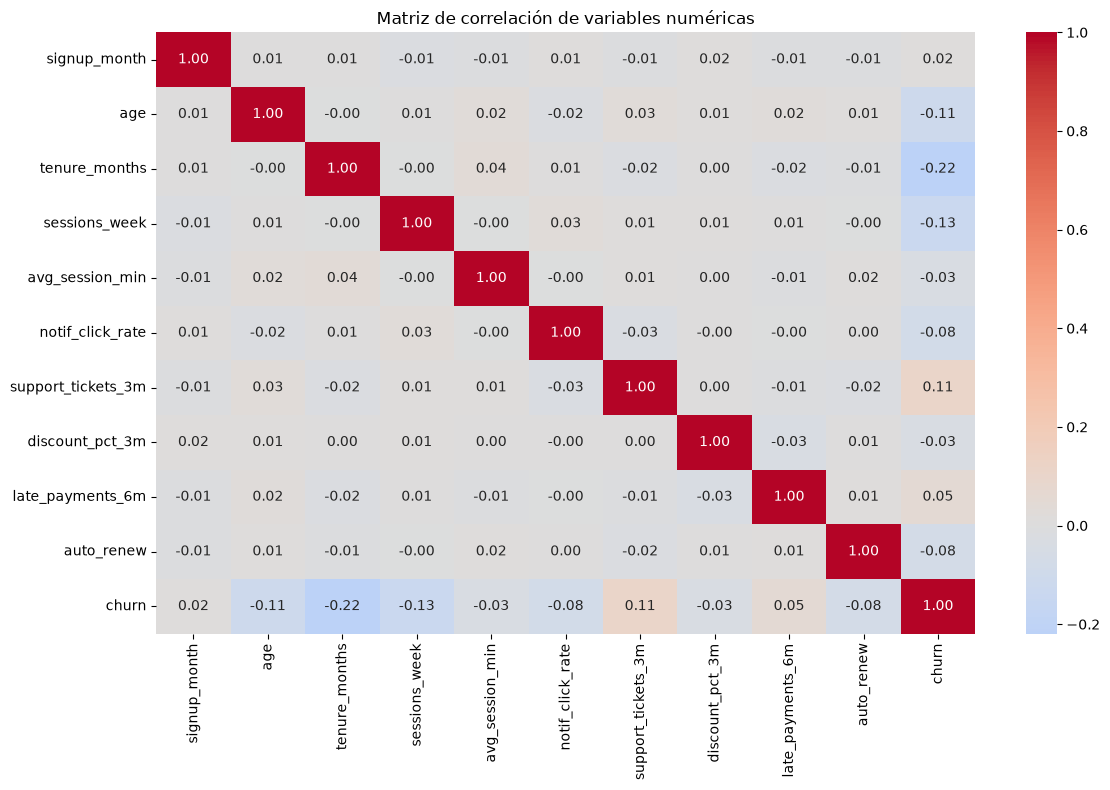

In [28]:
numeric_df = df.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación no muestra relaciones lineales fuertes entre las variables numéricas.

Respecto de la variable objetivo `churn`, la asociación lineal de mayor magnitud se observa con `tenure_months` (-0,22), indicando que una mayor antigüedad tiende a asociarse con una menor presencia de churn.

También se observan asociaciones negativas débiles con `sessions_week` (-0,13) y `age` (-0,11), mientras que `support_tickets_3m` presenta una asociación positiva débil (0,11).

El resto de las variables presenta correlaciones lineales de baja magnitud con la variable objetivo.

Estos resultados no implican relaciones causales y una correlación lineal baja no significa necesariamente que una variable carezca de capacidad predictiva, ya que los modelos de Machine Learning pueden identificar relaciones más complejas y no lineales.

## 6. Principales hallazgos del EDA

El análisis exploratorio permitió identificar los siguientes patrones:

- La variable objetivo se encuentra desbalanceada: aproximadamente el 24,36 % de los clientes presenta churn.
- Los clientes del plan Basic presentan una tasa de churn mayor que los clientes Premium.
- Los clientes sin renovación automática presentan una tasa de churn superior a aquellos con renovación automática.
- Los clientes que abandonan presentan, en promedio, menor antigüedad y menor cantidad de sesiones semanales.
- El grupo con churn registra una mayor cantidad promedio de tickets de soporte y ligeramente más pagos atrasados.
- La antigüedad (`tenure_months`) presenta la asociación lineal de mayor magnitud con el churn entre las variables numéricas analizadas.
- No se observan correlaciones lineales fuertes entre las variables numéricas.

Estos resultados proporcionan una primera comprensión de los factores asociados al churn y servirán como base para la etapa de ingeniería de características y posterior entrenamiento de modelos predictivos.